In [5]:
import pandas as pd
import numpy as np
df=pd.read_csv('marketing_campaign_data_messy.csv')
df.describe()

,Impressions,Clicks,Conversions,Clicks
count,2020.000000,2020.000000,1820.000000,40.000000
mean,49839.896040,1500.744059,186.085714,54856.200000
std,28579.637473,1084.765654,160.129172,30552.773369
min,1055.000000,11.000000,0.000000,2508.000000
25%,25033.500000,650.750000,68.000000,30164.750000
50%,50097.500000,1245.000000,142.000000,57707.500000
75%,74784.250000,2185.250000,257.000000,81497.500000
max,99875.000000,4812.000000,943.000000,99483.000000


In [6]:
df

,Campaign_ID,Campaign_Name,Start_Date,End_Date,Channel,Impressions,Clicks,Spend,Conversions,Active,Clicks,Campaign_Tag
0,CMP-00001,Q4_Summer_CMP-00001,2023-11-24 00:00:00,2023-12-13,TikTok,16795,197,$102.82,20.0,Y,NaN,TI
1,CMP-00002,Q1_Launch_CMP-00002,2023-05-06 00:00:00,2023-05-12,Facebook,1860,30,24.33,1.0,0,NaN,FA
2,CMP-00003,Q3_Winter_CMP-00003,2023-12-13 00:00:00,2023-12-20,Email,77820,843,1323.39,51.0,No,NaN,EM
3,CMP-00004,Q1_BlackFriday_CMP-00004,2023-10-30,2023-11-03,TikTok,55886,2019,2180.38,135.0,True,NaN,TI
4,CMP-00005,Q2_Winter_CMP-00005,2023-04-22 00:00:00,2023-04-23,Facebook,7265,169,252.44,30.0,Yes,NaN,FA
...,...,...,...,...,...,...,...,...,...,...,...,...
2015,CMP-00400,Q3_Summer_CMP-00400,2023-10-31 00:00:00,2023-11-13,TikTok,30592,586,$503.95,77.0,1,NaN,TI
2016,CMP-01255,Q4_Summer_CMP-01255,2023-09-01 00:00:00,2023-09-26,Google Ads,20097,897,1641.0,162.0,0,NaN,GO
2017,CMP-01050,Q2_Launch_CMP-01050,2023-02-09 00:00:00,2023-02-21,Instagram,33254,1117,883.82,214.0,0,NaN,IN
2018,CMP-01118,Q4_Winter_CMP-01118,2023-03-30 00:00:00,2023-04-27,Facebook,68728,2960,4198.5,591.0,Yes,NaN,FA


First, let's clean the `Spend` column. It currently has a `$` sign, which makes it an object type. We need to remove the `$` and convert it to a numeric type (float) so we can perform calculations and outlier detection on it.

In [7]:
# Remove '$' and convert 'Spend' to numeric
df['Spend'] = df['Spend'].astype(str).str.replace('$', '', regex=False).astype(float)

# Verify the change
print(df['Spend'].dtype)
display(df['Spend'].head())

float64


,Spend
0,102.82
1,24.33
2,1323.39
3,2180.38
4,252.44


Next, we address the duplicate 'Clicks' column. Looking at `df.describe()`, there are two 'Clicks' columns, one with 2020 entries and another with only 40. Based on the data display, the column at index 10 is the one with fewer entries and seems to be an anomalous column that should be removed. We'll drop this column to avoid ambiguity and cleaning the DataFrame.

In [8]:
# Drop the duplicate 'Clicks' column at index 10
df = df.drop(df.columns[10], axis=1)

# Verify the columns after dropping
print(df.columns)
display(df.describe())

Index([' Campaign_ID ', 'Campaign_Name', 'Start_Date', 'End_Date', 'Channel',
       'Impressions', 'Clicks ', 'Spend', 'Conversions', 'Active',
       'Campaign_Tag'],
      dtype='object')


,Impressions,Clicks,Spend,Conversions
count,2020.000000,2020.000000,2020.000000,1820.000000
mean,49839.896040,1500.744059,3094.844970,186.085714
std,28579.637473,1084.765654,24811.020701,160.129172
min,1055.000000,11.000000,-2503.310000,0.000000
25%,25033.500000,650.750000,649.997500,68.000000
50%,50097.500000,1245.000000,1427.105000,142.000000
75%,74784.250000,2185.250000,2638.382500,257.000000
max,99875.000000,4812.000000,500000.000000,943.000000


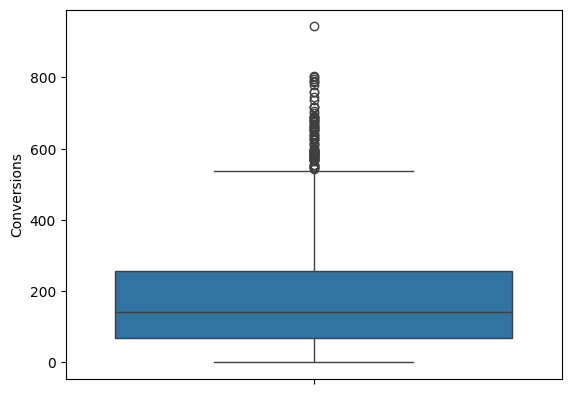

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
sns.boxplot(data=df,y=df['Conversions'])

plt.show()

What is IQR?
IQR stands for Interquartile Range. It's a measure of statistical dispersion, representing the range within which the central 50% of your data lies.

In [21]:
Q1=df["Conversions"].quantile(0.25)
# print(Q1)
Q3=df["Conversions"].quantile(0.75)
# print(Q3)
IQR= Q3-Q1
lower_bound= Q1-1.5*IQR
upper_bound= Q3+1.5*IQR

outliers=df[(df["Conversions"]<lower_bound)| (df["Conversions"]>upper_bound)]

print("\n--- Outlier Detection Result ---")
print(f"IQR: {IQR:.4f}")
print(f"Upper Outlier Threshold: {upper_bound:.4f} ")
print(f"Lower Outlier Threshold: {lower_bound:.4f} ")
print(f"Number of Outliers: {len(outliers)}")
print(outliers.sort_values(by="Conversions", ascending=False).head())



--- Outlier Detection Result ---
IQR: 189.0000
Upper Outlier Threshold: 540.5000 
Lower Outlier Threshold: -215.5000 
Number of Outliers: 88
      Campaign_ID         Campaign_Name           Start_Date    End_Date  \
1620     CMP-01621  Q2_Launch_CMP-01621  2023-10-12 00:00:00  2023-10-18   
317      CMP-00318  Q4_Summer_CMP-00318  2023-03-15 00:00:00  2023-03-22   
504      CMP-00505  Q2_Winter_CMP-00505  2023-06-24 00:00:00  2023-06-25   
1002     CMP-01003  Q1_Summer_CMP-01003  2023-07-16 00:00:00  2023-07-19   
1443     CMP-01444  Q1_Launch_CMP-01444  2023-01-09 00:00:00  2023-01-12   

         Channel  Impressions  Clicks     Spend  Conversions Active  \
1620       Email        98419     4812  2702.43        943.0  False   
317   Google Ads        92412     4120  5862.27        803.0      Y   
504   Google Ads        95758     4482  7363.14        801.0      1   
1002   Instagram        93436     4034  5447.27        794.0      1   
1443  Google Ads        97999     4620  8921.5

# Drop Outliers


In [22]:
df_dropped=df[(df["Conversions"]<=upper_bound)]
df_dropped.describe()

,Impressions,Clicks,Spend,Conversions
count,1732.000000,1732.000000,1732.000000,1732.000000
mean,47757.533487,1378.306005,2850.874509,162.916282
std,27875.389365,978.432208,23970.303817,124.643141
min,1055.000000,11.000000,-2162.500000,0.000000
25%,24222.750000,595.750000,604.107500,65.750000
50%,47527.000000,1156.500000,1342.920000,135.000000
75%,71316.000000,2033.000000,2364.895000,235.000000
max,99818.000000,4632.000000,500000.000000,537.000000


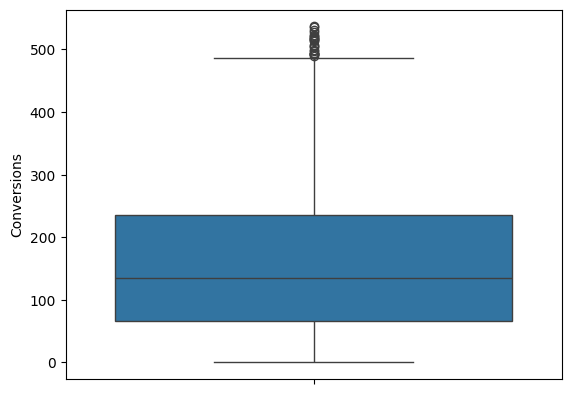

In [23]:
sns.boxplot(data=df_dropped, y="Conversions")
plt.show()

# Winsorization
Winsorization (Capping), a method used to handle outliers by replacing extreme values with values closer to the rest of the data, rather than removing them entirely. This approach is useful when the outliers represent valid data points that should not be deleted.

In [25]:
cap_value=df["Conversions"].quantile(0.995)
# print(cap_value)
df_capped=df.copy()
df_capped["Conversions"]=np.where(df_capped["Conversions"]>cap_value, cap_value,df_capped["Conversions"] )
df_capped.describe()


,Impressions,Clicks,Spend,Conversions
count,2020.000000,2020.000000,2020.000000,1820.000000
mean,49839.896040,1500.744059,3094.844970,185.856484
std,28579.637473,1084.765654,24811.020701,159.234438
min,1055.000000,11.000000,-2503.310000,0.000000
25%,25033.500000,650.750000,649.997500,68.000000
50%,50097.500000,1245.000000,1427.105000,142.000000
75%,74784.250000,2185.250000,2638.382500,257.000000
max,99875.000000,4812.000000,500000.000000,758.480000


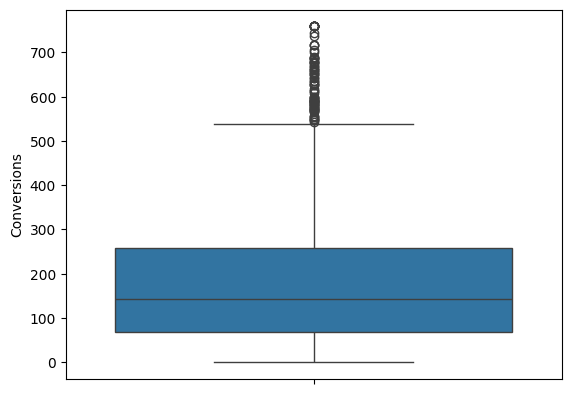

In [26]:
sns.boxplot(data=df_capped, y="Conversions")
plt.show()

In [27]:
print("\n--- Business Impact Comparison ---")
print(f"Original Dataset Mean Rooms: {df['Conversions'].mean():.2f}")
print(f"Original Dataset Max Rooms:  {df['Conversions'].max():.2f}\n")

print(f"After DROPPING - Mean Rooms: {df_dropped['Conversions'].mean():.2f}")
print(f"After DROPPING - Max Rooms:  {df_dropped['Conversions'].max():.2f}\n")

print(f"After CAPPING  - Mean Rooms: {df_capped['Conversions'].mean():.2f}")
print(f"After CAPPING  - Max Rooms:  {df_capped['Conversions'].max():.2f}")


--- Business Impact Comparison ---
Original Dataset Mean Rooms: 186.09
Original Dataset Max Rooms:  943.00

After DROPPING - Mean Rooms: 162.92
After DROPPING - Max Rooms:  537.00

After CAPPING  - Mean Rooms: 185.86
After CAPPING  - Max Rooms:  758.48
